In [1]:
from datetime import datetime

import duckdb
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import polars as pl
import seaborn as sns
import shapely

from wpp import data, db
from wpp.utils import project_root

In [2]:
# config
sns.set_theme(style="ticks")
pl.Config.set_engine_affinity("streaming")

root = project_root()
db_path = root / "rofl.duckdb"
con = db.connect(db_path)

In [59]:
states = con.sql("SELECT DISTINCT STATEFP FROM block_groups ORDER BY 1").pl()["STATEFP"].to_list()

In [60]:
def get_df(state) -> gpd.GeoDataFrame:
    df = con.sql(f"""
        with bg as (
            select *
            from block_groups
            where statefp = '{state}'
        )
        select *
        from pois p
        join bg
          on bg.geom && p.geom
         and ST_Within(p.geom, bg.geom)
    """).df()
    df['geom'] = df['GEOM'].apply(lambda g: shapely.wkb.loads(bytes(g)) if g is not None else None)
    gdf = gpd.GeoDataFrame(df, geometry='geom', crs='EPSG:4326')
    return gdf

In [63]:
def get_bg(state) -> gpd.GeoDataFrame:
    bg = con.sql(f"""
        SELECT *
        FROM block_groups
        WHERE STATEFP = '{state}'
    """).df()
    bg['geom'] = bg['geom'].apply(lambda g: shapely.wkb.loads(bytes(g)) if g is not None else None)
    gbg = gpd.GeoDataFrame(bg, geometry='geom', crs='EPSG:4326')
    gbg["geom"] = gbg.boundary
    return gbg

ConnectionError: ('Connection aborted.', ConnectionResetError(54, 'Connection reset by peer'))

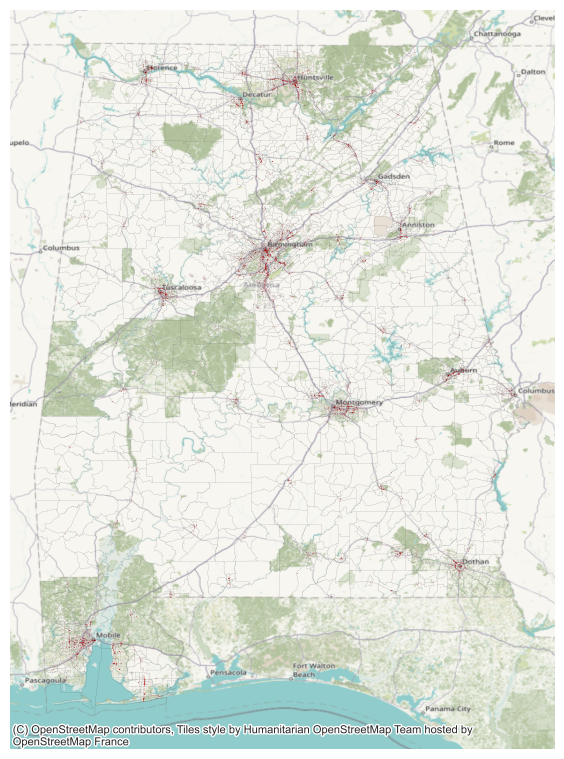

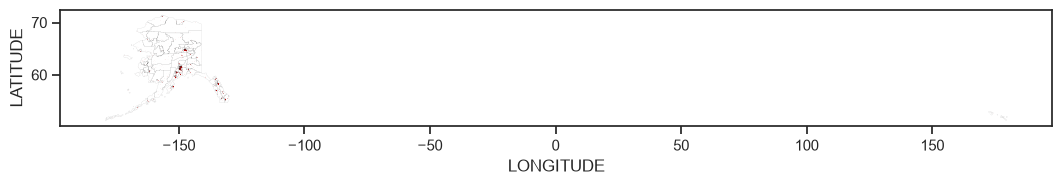

In [64]:
fig_scale = 2
for state in states:
    df = get_df(state)
    gbg = get_bg(state)
    fig, ax = plt.subplots(figsize=(6.4*fig_scale, 4.8*fig_scale))
    gbg.plot(ax=ax, color="#444", linewidth=0.1, alpha=.4)
    sns.scatterplot(
        df, x="LONGITUDE", y="LATITUDE",
        color="#c00", s=1,
        alpha=.01, legend=False,
        ax=ax
    )
    cx.add_basemap(ax, crs="EPSG:4326", zoom=8)
    ax.set_axis_off()
    ax.set_aspect("equal")
    fig.savefig(f"state_{state}.png")